In [2]:
import pandas as pd
distance=pd.read_excel('D:\Code\pycharm\AANE对比实验\抗原距离预测.xlsx')
distance
aane=distance[['virus_num','serum_num','distance2','distance_pre_aane','antigentic_aane']]
yichuanjuli=pd.read_csv('D:\Code\pycharm\AANE对比实验\遗传距离.txt',sep='\t')
node=pd.read_excel('D:\Code\pycharm\AANE对比实验\data\序列数据.xlsx')
yichuanjuli
gene=pd.read_excel('D:\Code\pycharm\AANE对比实验\遗传距离.xlsx')
gene

,Unnamed: 0,viruStrain_x,virus_num,viruStrain_y,serum_num,genetic_distance,virus_seq,serum_seq,virus_year,serum_year,region_x,region_y
0,0,A/Akita/4/1993,0,A/Akita/4/1993,0,0.000000,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1993,1993,Japan Korea,Japan Korea
1,1,A/Alabama/5/2010,1,A/Akita/4/1993,0,0.121581,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,2010,1993,North America,Japan Korea
2,2,A/Alaska/5/2010,2,A/Akita/4/1993,0,0.127660,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,2010,1993,North America,Japan Korea
3,3,A/Algeria/G202/2009,3,A/Akita/4/1993,0,0.103343,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,2008,1993,Africa,Japan Korea
4,4,A/Amsterdam/1609/1977,4,A/Akita/4/1993,0,0.124620,QDLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1977,1993,Europe,Japan Korea
...,...,...,...,...,...,...,...,...,...,...,...,...
161599,161599,A/Wyoming/2/2003,397,A/Yamagata/62/1993,401,0.094512,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,2003,1993,North America,Japan Korea
161600,161600,A/Wyoming/3/2003,398,A/Yamagata/62/1993,401,0.097561,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,2003,1993,North America,Japan Korea
161601,161601,A/Yamagata/56/1993,399,A/Yamagata/62/1993,401,0.000000,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1993,1993,Japan Korea,Japan Korea
161602,161602,A/Yamagata/61/1993,400,A/Yamagata/62/1993,401,0.000000,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1993,1993,Japan Korea,Japan Korea


In [3]:
strain_name=list(node['viruStrain'])
seq_to_idx={strain_name:i for i,strain_name in enumerate(strain_name)}
seq_to_idx

{'A/Akita/4/1993': 0,
 'A/Alabama/5/2010': 1,
 'A/Alaska/5/2010': 2,
 'A/Algeria/G202/2009': 3,
 'A/Amsterdam/1609/1977': 4,
 'A/Anhui/1238/2005': 5,
 'A/Anhui/1239/2005': 6,
 'A/Atlanta/211/1989': 7,
 'A/Atlanta/3572/1988': 8,
 'A/Auckland/10/1997': 9,
 'A/Auckland/4382/1982': 10,
 'A/Auckland/6/2003': 11,
 'A/BadenWuerttemberg/38/2005': 12,
 'A/Bangkok/1/1979': 13,
 'A/Bangladesh/5071/2011': 14,
 'A/Beijing/32/1992': 15,
 'A/Beijing/352/1989': 16,
 'A/Beijing/353/1989': 17,
 'A/Beijing/51/2002': 18,
 'A/Bilthoven/10684/1982': 19,
 'A/Bilthoven/15793/1968': 20,
 'A/Bilthoven/16190/1968': 21,
 'A/Bilthoven/16398/1968': 22,
 'A/Bilthoven/1761/1976': 23,
 'A/Bilthoven/17938/1969': 24,
 'A/Bilthoven/1843/1975': 25,
 'A/Bilthoven/21438/1971': 26,
 'A/Bilthoven/21793/1972': 27,
 'A/Bilthoven/21801/1971': 28,
 'A/Bilthoven/2271/1976': 29,
 'A/Bilthoven/23290/1972': 30,
 'A/Bilthoven/23337/1972': 31,
 'A/Bilthoven/2600/1975': 32,
 'A/Bilthoven/2668/1970': 33,
 'A/Bilthoven/2813/1975': 34,
 'A

In [4]:
node=node.reset_index()
con1=pd.merge(yichuanjuli,node,left_on='0',right_on='viruStrain')
con1=con1.reset_index()
con1
con2=pd.merge(con1,node,left_on='variable',right_on='viruStrain')

con2=pd.concat([con2,pd.DataFrame(columns=['indexon'])])
con2

,level_0,0,variable,value,index_x,viruStrain_x,year_x,seq_x,date_x,region_x,index_y,viruStrain_y,year_y,seq_y,date_y,region_y,indexon
0,0.0,A/Akita/4/1993,A/Akita/4/1993,0.000000,0.0,A/Akita/4/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930101.0,Japan Korea,0.0,A/Akita/4/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930101.0,Japan Korea,NaN
1,402.0,A/Alabama/5/2010,A/Akita/4/1993,0.121581,1.0,A/Alabama/5/2010,2010.0,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,20091101.0,North America,0.0,A/Akita/4/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930101.0,Japan Korea,NaN
2,804.0,A/Alaska/5/2010,A/Akita/4/1993,0.127660,2.0,A/Alaska/5/2010,2010.0,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,20110916.0,North America,0.0,A/Akita/4/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930101.0,Japan Korea,NaN
3,1206.0,A/Algeria/G202/2009,A/Akita/4/1993,0.103343,3.0,A/Algeria/G202/2009,2008.0,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,20101205.0,Africa,0.0,A/Akita/4/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930101.0,Japan Korea,NaN
4,1608.0,A/Amsterdam/1609/1977,A/Akita/4/1993,0.124620,4.0,A/Amsterdam/1609/1977,1977.0,QDLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19801201.0,Europe,0.0,A/Akita/4/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930101.0,Japan Korea,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161599,159995.0,A/Wyoming/2/2003,A/Yamagata/62/1993,0.094512,397.0,A/Wyoming/2/2003,2003.0,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,20031028.0,North America,401.0,A/Yamagata/62/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930112.0,Japan Korea,NaN
161600,160397.0,A/Wyoming/3/2003,A/Yamagata/62/1993,0.097561,398.0,A/Wyoming/3/2003,2003.0,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,20031028.0,North America,401.0,A/Yamagata/62/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930112.0,Japan Korea,NaN
161601,160799.0,A/Yamagata/56/1993,A/Yamagata/62/1993,0.000000,399.0,A/Yamagata/56/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930223.0,Japan Korea,401.0,A/Yamagata/62/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930112.0,Japan Korea,NaN
161602,161201.0,A/Yamagata/61/1993,A/Yamagata/62/1993,0.000000,400.0,A/Yamagata/61/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930112.0,Japan Korea,401.0,A/Yamagata/62/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930112.0,Japan Korea,NaN


In [5]:
con2.rename(columns={'index_x':'virus_num','index_y':'serum_num','seq_x':'virus_seq','seq_y':'serum_seq','year_x':'virus_year','year_y':'serum_year','value':'genetic_distance'},inplace=True)
con2

,level_0,0,variable,genetic_distance,virus_num,viruStrain_x,virus_year,virus_seq,date_x,region_x,serum_num,viruStrain_y,serum_year,serum_seq,date_y,region_y,indexon
0,0.0,A/Akita/4/1993,A/Akita/4/1993,0.000000,0.0,A/Akita/4/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930101.0,Japan Korea,0.0,A/Akita/4/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930101.0,Japan Korea,NaN
1,402.0,A/Alabama/5/2010,A/Akita/4/1993,0.121581,1.0,A/Alabama/5/2010,2010.0,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,20091101.0,North America,0.0,A/Akita/4/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930101.0,Japan Korea,NaN
2,804.0,A/Alaska/5/2010,A/Akita/4/1993,0.127660,2.0,A/Alaska/5/2010,2010.0,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,20110916.0,North America,0.0,A/Akita/4/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930101.0,Japan Korea,NaN
3,1206.0,A/Algeria/G202/2009,A/Akita/4/1993,0.103343,3.0,A/Algeria/G202/2009,2008.0,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,20101205.0,Africa,0.0,A/Akita/4/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930101.0,Japan Korea,NaN
4,1608.0,A/Amsterdam/1609/1977,A/Akita/4/1993,0.124620,4.0,A/Amsterdam/1609/1977,1977.0,QDLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19801201.0,Europe,0.0,A/Akita/4/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930101.0,Japan Korea,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161599,159995.0,A/Wyoming/2/2003,A/Yamagata/62/1993,0.094512,397.0,A/Wyoming/2/2003,2003.0,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,20031028.0,North America,401.0,A/Yamagata/62/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930112.0,Japan Korea,NaN
161600,160397.0,A/Wyoming/3/2003,A/Yamagata/62/1993,0.097561,398.0,A/Wyoming/3/2003,2003.0,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,20031028.0,North America,401.0,A/Yamagata/62/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930112.0,Japan Korea,NaN
161601,160799.0,A/Yamagata/56/1993,A/Yamagata/62/1993,0.000000,399.0,A/Yamagata/56/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930223.0,Japan Korea,401.0,A/Yamagata/62/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930112.0,Japan Korea,NaN
161602,161201.0,A/Yamagata/61/1993,A/Yamagata/62/1993,0.000000,400.0,A/Yamagata/61/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930112.0,Japan Korea,401.0,A/Yamagata/62/1993,1993.0,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,19930112.0,Japan Korea,NaN


In [6]:
distance=con2[['viruStrain_x','virus_num','viruStrain_y','serum_num','genetic_distance','virus_seq','serum_seq','virus_year','serum_year','region_x','region_y']]

In [7]:
distance_all=pd.merge(aane,
         distance,
         how='inner',
         left_on=['virus_num','serum_num'],
         right_on=['virus_num','serum_num']
        )
distance_all

,virus_num,serum_num,distance2,distance_pre_aane,antigentic_aane,viruStrain_x,viruStrain_y,genetic_distance,virus_seq,serum_seq,virus_year,serum_year,region_x,region_y
0,0,15,1.369564,2.012104,0,A/Akita/4/1993,A/Beijing/32/1992,0.015198,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1993.0,1992.0,Japan Korea,China
1,0,17,5.217231,5.835397,1,A/Akita/4/1993,A/Beijing/353/1989,0.036474,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1993.0,1989.0,Japan Korea,China
2,0,88,0.294008,0.643700,0,A/Akita/4/1993,A/Finland/338/1995,0.033435,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1993.0,1995.0,Japan Korea,Europe
3,0,102,2.576925,5.411043,1,A/Akita/4/1993,A/Guangdong/25/1993,0.018237,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1993.0,1993.0,Japan Korea,China
4,0,164,8.000000,7.065335,1,A/Akita/4/1993,A/Lyon/1149/1991,0.039514,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1993.0,1991.0,Japan Korea,Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4282,392,393,0.514573,1.108509,0,A/Wisconsin/67/2005,A/Wisconsin/68/2005,0.021277,QKLPGNDDSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2005.0,2005.0,North America,North America
4283,392,396,1.415037,3.253401,0,A/Wisconsin/67/2005,A/Wyoming/1/2006,0.021277,QKLPGNDDSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2005.0,2006.0,North America,North America
4284,392,398,2.892998,3.715360,0,A/Wisconsin/67/2005,A/Wyoming/3/2003,0.036474,QKLPGNDDSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2005.0,2003.0,North America,North America
4285,395,398,3.892998,5.001827,1,A/Wyoming/0049/2005,A/Wyoming/3/2003,0.024316,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2005.0,2003.0,North America,North America


In [932]:
year=distance_all[(distance_all['virus_year']==2009)|(distance_all['virus_year']==2010)|(distance_all['virus_year']==2011)]
year=year[(year['serum_year']==2009) |(year['serum_year']==2010)|(year['serum_year']==2011)]
year

,virus_num,serum_num,distance2,distance_pre_aane,antigentic_aane,viruStrain_x,viruStrain_y,genetic_distance,virus_seq,serum_seq,virus_year,serum_year,region_x,region_y
14,1,2,2.0,0.550645,0,A/Alabama/5/2010,A/Alaska/5/2010,0.024316,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2010.0,2010.0,North America,North America
16,1,93,1.0,0.929449,0,A/Alabama/5/2010,A/Florida/43/2010,0.009146,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2010.0,2010.0,North America,North America
17,1,100,1.0,0.269291,0,A/Alabama/5/2010,A/Guadeloupe/202/2010,0.015198,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2010.0,2010.0,North America,Europe
18,1,122,1.0,2.310175,0,A/Alabama/5/2010,A/HongKong/3170/2010,0.042553,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2010.0,2010.0,North America,China
19,1,129,1.0,2.643672,0,A/Alabama/5/2010,A/HongKong/3969/2011,0.033435,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQNS...,2010.0,2011.0,North America,China
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4221,365,373,7.0,5.947000,1,A/Uppsala/3/2011,A/Victoria/210/2009,0.036585,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQNS...,2011.0,2009.0,Europe,North America
4222,365,389,2.0,2.877845,0,A/Uppsala/3/2011,A/Wisconsin/15/2009,0.030395,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2011.0,2009.0,Europe,North America
4238,372,373,0.0,0.000000,0,A/Victoria/208/2009,A/Victoria/210/2009,0.021341,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQNS...,2009.0,2009.0,North America,North America
4239,372,389,3.0,2.561481,0,A/Victoria/208/2009,A/Wisconsin/15/2009,0.015198,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2009.0,2009.0,North America,North America


In [1023]:
year2=year[(distance_all['virus_num']==372)|(distance_all['serum_num']==372)]
year2

C:\Users\15285\AppData\Local\Temp/ipykernel_11788/246450875.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  year2=year[(distance_all['virus_num']==372)|(distance_all['serum_num']==372)]


,virus_num,serum_num,distance2,distance_pre_aane,antigentic_aane,viruStrain_x,viruStrain_y,genetic_distance,virus_seq,serum_seq,virus_year,serum_year,region_x,region_y
31,1,372,7.0,6.752525,1,A/Alabama/5/2010,A/Victoria/208/2009,0.018237,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2010.0,2009.0,North America,North America
61,2,372,2.0,3.283622,0,A/Alaska/5/2010,A/Victoria/208/2009,0.027356,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2010.0,2009.0,North America,North America
304,14,372,7.0,7.045860,1,A/Bangladesh/5071/2011,A/Victoria/208/2009,0.012158,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2011.0,2009.0,South Asia,North America
927,56,372,4.0,3.741055,0,A/Bratislava/31/2011,A/Victoria/208/2009,0.021277,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDRIEVTNATELVQNS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2011.0,2009.0,Europe,North America
1044,59,372,7.0,5.054152,1,A/Brisbane/11/2010,A/Victoria/208/2009,0.009119,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2010.0,2009.0,Oceania,North America
1413,77,372,5.0,2.354335,0,A/Durban/92/2011,A/Victoria/208/2009,0.009119,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2011.0,2009.0,West Asia,North America
1794,100,372,1.0,2.868517,0,A/Guadeloupe/202/2010,A/Victoria/208/2009,0.021277,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2010.0,2009.0,Europe,North America
2057,115,372,7.0,7.885384,1,A/HongKong/1985/2009,A/Victoria/208/2009,0.009119,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2009.0,2009.0,China,North America
2162,125,372,7.0,7.822168,1,A/HongKong/34430/2009,A/Victoria/208/2009,0.012158,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2009.0,2009.0,China,North America
2204,129,372,1.0,2.882896,0,A/HongKong/3969/2011,A/Victoria/208/2009,0.015198,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQNS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2011.0,2009.0,China,North America


In [1024]:
year2[['distance2','genetic_distance']].mean()

distance2           4.500000
genetic_distance    0.012431
dtype: float64

In [367]:
year1=distance_all[(distance_all['virus_year']==1973)|(distance_all['virus_year']==1974)|(distance_all['virus_year']==1975)|(distance_all['virus_year']==1976)|(distance_all['virus_year']==1977)]
year1=year1[(year1['serum_year']==1979)|(year1['serum_year']==1980)|(year1['serum_year']==1981)|(year1['serum_year']==1982)|(year1['serum_year']==1983)|(year1['serum_year']==1984)|(year1['serum_year']==1985)|(year1['serum_year']==1986)]
year1

,virus_num,serum_num,distance2,distance_pre_aane,antigentic_aane,viruStrain_x,viruStrain_y,genetic_distance,virus_seq,serum_seq,virus_year,serum_year,region_x,region_y
73,4,13,7.000000,6.419670,1,A/Amsterdam/1609/1977,A/Bangkok/1/1979,0.075988,QDLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QNLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1977.0,1979.0,Europe,Southeast Asia
105,4,207,3.000000,2.764599,0,A/Amsterdam/1609/1977,A/Netherlands/209/1980,0.075988,QDLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QNLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1977.0,1980.0,Europe,Europe
106,4,209,3.000000,3.428460,0,A/Amsterdam/1609/1977,A/Netherlands/241/1982,0.079027,QDLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QNLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1977.0,1982.0,Europe,Europe
108,4,216,3.702833,2.510023,0,A/Amsterdam/1609/1977,A/Netherlands/330/1985,0.088146,QDLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1977.0,1985.0,Europe,Europe
111,4,278,3.954196,2.075655,0,A/Amsterdam/1609/1977,A/Philippines/2/1982,0.088146,QDLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QNLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1977.0,1982.0,Europe,North America
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3860,287,386,5.750205,5.674146,1,A/Rotterdam/5828/1977,A/Wellington/4/1985,0.088146,QDLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1977.0,1985.0,Europe,Oceania
3861,288,324,5.499846,6.293994,1,A/Rotterdam/8179/1977,A/Stockholm/10/1985,0.091185,QDLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1977.0,1985.0,Europe,Europe
3865,288,386,3.750205,3.072305,0,A/Rotterdam/8179/1977,A/Wellington/4/1985,0.082067,QDLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1977.0,1985.0,Europe,Oceania
4181,351,386,2.248765,2.732767,0,A/Texas/1/1977,A/Wellington/4/1985,0.051672,QNLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1977.0,1985.0,North America,Oceania


In [357]:
yearnew=pd.concat([year,year1])
yearnew

,virus_num,serum_num,distance2,distance_pre_aane,antigentic_aane,viruStrain_x,viruStrain_y,genetic_distance,virus_seq,serum_seq,virus_year,serum_year,region_x,region_y
213,10,351,2.000000,1.247004,0,A/Auckland/4382/1982,A/Texas/1/1977,0.042553,QNLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QNLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1982.0,1977.0,Oceania,North America
245,13,23,7.000000,6.503331,1,A/Bangkok/1/1979,A/Bilthoven/1761/1976,0.072948,QNLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QDLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1979.0,1976.0,Southeast Asia,Europe
250,13,29,4.000000,3.348037,0,A/Bangkok/1/1979,A/Bilthoven/2271/1976,0.051672,QNLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QDLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1979.0,1976.0,Southeast Asia,Europe
252,13,35,7.000000,6.510864,1,A/Bangkok/1/1979,A/Bilthoven/334/1975,0.060790,QNLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QDLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1979.0,1975.0,Southeast Asia,Europe
253,13,36,7.000000,5.391301,1,A/Bangkok/1/1979,A/Bilthoven/3517/1973,0.075988,QNLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QDFPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1979.0,1973.0,Southeast Asia,Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3860,287,386,5.750205,5.674146,1,A/Rotterdam/5828/1977,A/Wellington/4/1985,0.088146,QDLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1977.0,1985.0,Europe,Oceania
3861,288,324,5.499846,6.293994,1,A/Rotterdam/8179/1977,A/Stockholm/10/1985,0.091185,QDLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1977.0,1985.0,Europe,Europe
3865,288,386,3.750205,3.072305,0,A/Rotterdam/8179/1977,A/Wellington/4/1985,0.082067,QDLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1977.0,1985.0,Europe,Oceania
4181,351,386,2.248765,2.732767,0,A/Texas/1/1977,A/Wellington/4/1985,0.051672,QNLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1977.0,1985.0,North America,Oceania


In [358]:
yearnew[['distance2','genetic_distance']].mean()

distance2           5.519823
genetic_distance    0.081486
dtype: float64

In [277]:
gene1=gene[gene['virus_year']==2009]
gene1=gene1[(gene1['serum_year']==2007) | (gene1['serum_year']==2008)]
gene1

,Unnamed: 0,viruStrain_x,virus_num,viruStrain_y,serum_num,genetic_distance,virus_seq,serum_seq,virus_year,serum_year,region_x,region_y
1276,1276,A/Cameroon/675/2009,70,A/Algeria/G202/2009,3,0.009119,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2009,2008,Africa,Africa
1320,1320,A/HongKong/1952/2009,114,A/Algeria/G202/2009,3,0.015198,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2009,2008,China,Africa
1321,1321,A/HongKong/1985/2009,115,A/Algeria/G202/2009,3,0.012158,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2009,2008,China,Africa
1325,1325,A/HongKong/26560/2009,119,A/Algeria/G202/2009,3,0.024316,QKIPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2009,2008,China,Africa
1331,1331,A/HongKong/34430/2009,125,A/Algeria/G202/2009,3,0.015198,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2009,2008,China,Africa
...,...,...,...,...,...,...,...,...,...,...,...,...
157520,157520,A/Sweden/2/2009,338,A/Wisconsin/3/2007,391,0.027356,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2009,2007,Europe,North America
157546,157546,A/Umea/4/2009,364,A/Wisconsin/3/2007,391,0.024316,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2009,2007,Europe,North America
157554,157554,A/Victoria/208/2009,372,A/Wisconsin/3/2007,391,0.018237,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2009,2007,North America,North America
157555,157555,A/Victoria/210/2009,373,A/Wisconsin/3/2007,391,0.027439,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQNS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2009,2007,North America,North America


In [278]:
gene2=gene[(gene['virus_year']==2007) | (gene['virus_year']==2008)]
gene2=gene2[gene2['serum_year']==2009]
gene2

,Unnamed: 0,viruStrain_x,virus_num,viruStrain_y,serum_num,genetic_distance,virus_seq,serum_seq,virus_year,serum_year,region_x,region_y
28143,28143,A/Algeria/G202/2009,3,A/Cameroon/675/2009,70,0.009119,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2008,2009,Africa,Africa
28198,28198,A/Brisbane/10/2007,58,A/Cameroon/675/2009,70,0.015198,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2009,Oceania,Africa
28200,28200,A/Brisbane/24/2008,60,A/Cameroon/675/2009,70,0.024316,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2008,2009,Oceania,Africa
28220,28220,A/England/392/2008,80,A/Cameroon/675/2009,70,0.009146,-KLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2008,2009,Europe,Africa
28221,28221,A/England/394/2008,81,A/Cameroon/675/2009,70,0.012195,-KLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2008,2009,Europe,Africa
...,...,...,...,...,...,...,...,...,...,...,...,...
156730,156730,A/Texas/37/2007,352,A/Wisconsin/15/2009,389,0.024390,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2009,North America,North America
156734,156734,A/Torino/14/2008,356,A/Wisconsin/15/2009,389,0.018293,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2008,2009,Europe,North America
156738,156738,A/Trieste/25c/2007,360,A/Wisconsin/15/2009,389,0.021277,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2009,Europe,North America
156744,156744,A/Uruguay/716/2007,366,A/Wisconsin/15/2009,389,0.021277,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2009,South America,North America


In [279]:
genenew=pd.concat([gene1,gene2])
genenew

,Unnamed: 0,viruStrain_x,virus_num,viruStrain_y,serum_num,genetic_distance,virus_seq,serum_seq,virus_year,serum_year,region_x,region_y
1276,1276,A/Cameroon/675/2009,70,A/Algeria/G202/2009,3,0.009119,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2009,2008,Africa,Africa
1320,1320,A/HongKong/1952/2009,114,A/Algeria/G202/2009,3,0.015198,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2009,2008,China,Africa
1321,1321,A/HongKong/1985/2009,115,A/Algeria/G202/2009,3,0.012158,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2009,2008,China,Africa
1325,1325,A/HongKong/26560/2009,119,A/Algeria/G202/2009,3,0.024316,QKIPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2009,2008,China,Africa
1331,1331,A/HongKong/34430/2009,125,A/Algeria/G202/2009,3,0.015198,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2009,2008,China,Africa
...,...,...,...,...,...,...,...,...,...,...,...,...
156730,156730,A/Texas/37/2007,352,A/Wisconsin/15/2009,389,0.024390,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2009,North America,North America
156734,156734,A/Torino/14/2008,356,A/Wisconsin/15/2009,389,0.018293,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2008,2009,Europe,North America
156738,156738,A/Trieste/25c/2007,360,A/Wisconsin/15/2009,389,0.021277,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2009,Europe,North America
156744,156744,A/Uruguay/716/2007,366,A/Wisconsin/15/2009,389,0.021277,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2009,South America,North America


In [280]:
genenew.mean()

C:\Users\15285\AppData\Local\Temp/ipykernel_11788/141031502.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  genenew.mean()


Unnamed: 0          95671.157759
virus_num             237.397414
serum_num             237.397414
genetic_distance        0.018838
virus_year           2008.327586
serum_year           2008.327586
dtype: float64

In [53]:
# 抗原距离按年份分析
byyear=pd.read_excel('D:\Code\pycharm\AANE对比实验\不同年份之间的遗传距离和抗原距离.xlsx')
byyear

,year1,year2,antigenic distance,genetic distance,label,clutser1,cluster2,antigenic distance1,genetic distance1
0,1968,1969,1.025213,0.009372,NaN,1981.0,1982.0,0.750077,0.030395
1,1969,1970,1.117651,0.010149,NaN,1982.0,1984.0,3.727973,0.021277
2,1970,1971,2.978416,0.027016,NaN,NaN,NaN,NaN,NaN
3,1971,1972,3.676882,0.031915,NaN,NaN,NaN,NaN,NaN
4,1972,1973,1.555093,0.017097,NaN,NaN,NaN,NaN,NaN
5,1973,1974,0.912233,0.021884,NaN,NaN,NaN,NaN,NaN
6,1974,1975,3.388874,0.033941,NaN,NaN,NaN,NaN,NaN
7,1975,1976,1.402506,0.018744,NaN,NaN,NaN,NaN,NaN
8,1976,1977,2.101132,0.029483,NaN,NaN,NaN,NaN,NaN
9,1979,1980,2.292636,0.010638,NaN,NaN,NaN,NaN,NaN


In [1025]:
both=pd.read_excel('D:\Code\pycharm\AANE对比实验\遗传距离和抗原距离.xlsx')
both

,Unnamed: 0,virus_num,serum_num,distance2,distance_pre_aane,antigentic_aane,viruStrain_x,viruStrain_y,genetic_distance,virus_seq,serum_seq,virus_year,serum_year,region_x,region_y
0,0,0,15,1.369564,2.012104,0,A/Akita/4/1993,A/Beijing/32/1992,0.015198,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1993,1992,Japan Korea,China
1,1,0,17,5.217231,5.835397,1,A/Akita/4/1993,A/Beijing/353/1989,0.036474,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1993,1989,Japan Korea,China
2,2,0,88,0.294008,0.643700,0,A/Akita/4/1993,A/Finland/338/1995,0.033435,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1993,1995,Japan Korea,Europe
3,3,0,102,2.576925,5.411043,1,A/Akita/4/1993,A/Guangdong/25/1993,0.018237,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1993,1993,Japan Korea,China
4,4,0,164,8.000000,7.065335,1,A/Akita/4/1993,A/Lyon/1149/1991,0.039514,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTLVKTITNDQIEVTNATELVQSS...,1993,1991,Japan Korea,Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4282,4282,392,393,0.514573,1.108509,0,A/Wisconsin/67/2005,A/Wisconsin/68/2005,0.021277,QKLPGNDDSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2005,2005,North America,North America
4283,4283,392,396,1.415037,3.253401,0,A/Wisconsin/67/2005,A/Wyoming/1/2006,0.021277,QKLPGNDDSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2005,2006,North America,North America
4284,4284,392,398,2.892998,3.715360,0,A/Wisconsin/67/2005,A/Wyoming/3/2003,0.036474,QKLPGNDDSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2005,2003,North America,North America
4285,4285,395,398,3.892998,5.001827,1,A/Wyoming/0049/2005,A/Wyoming/3/2003,0.024316,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2005,2003,North America,North America


In [1147]:
both1=both[(both['virus_year']==2000)|(both['virus_year']==2001)|(both['virus_year']==2002)|(both['virus_year']==2003)|(both['virus_year']==2004)|(both['virus_year']==2005)|(both['virus_year']==2006)|(both['virus_year']==2007)|(both['virus_year']==2008)]
both1=both1[(both1['serum_year']==2009)|(both1['serum_year']==2010)|(both1['serum_year']==2011)]
both1

,Unnamed: 0,virus_num,serum_num,distance2,distance_pre_aane,antigentic_aane,viruStrain_x,viruStrain_y,genetic_distance,virus_seq,serum_seq,virus_year,serum_year,region_x,region_y
962,962,58,59,7.0,6.091983,1,A/Brisbane/10/2007,A/Brisbane/11/2010,0.024316,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2010,Oceania,Oceania
966,966,58,70,5.0,5.203058,1,A/Brisbane/10/2007,A/Cameroon/675/2009,0.015198,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2009,Oceania,Africa
967,967,58,77,7.0,5.673444,1,A/Brisbane/10/2007,A/Durban/92/2011,0.024316,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2011,Oceania,West Asia
973,973,58,100,4.0,4.525505,1,A/Brisbane/10/2007,A/Guadeloupe/202/2010,0.030395,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2010,Oceania,Europe
974,974,58,114,3.0,2.000336,0,A/Brisbane/10/2007,A/HongKong/1952/2009,0.021277,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2009,Oceania,China
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4224,4224,366,367,6.0,6.258411,1,A/Uruguay/716/2007,A/Uvurkhangai/3970/2010,0.030395,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2010,South America,West Asia
4225,4225,366,372,5.0,4.833332,1,A/Uruguay/716/2007,A/Victoria/208/2009,0.018237,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2009,South America,North America
4226,4226,366,373,7.0,6.420311,1,A/Uruguay/716/2007,A/Victoria/210/2009,0.033537,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQNS...,2007,2009,South America,North America
4227,4227,366,388,8.0,10.342531,1,A/Uruguay/716/2007,A/Wisconsin/13/2010,0.036697,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2010,South America,North America


In [1148]:
both2=both[(both['serum_year']==2009)|(both['serum_year']==2010)|(both['serum_year']==2011)]
both2=both2[(both1['virus_year']==2000)|(both2['virus_year']==2001)|(both2['virus_year']==2002)|(both2['virus_year']==2003)|(both2['virus_year']==2004)|(both2['virus_year']==2005)|(both2['virus_year']==2006)|(both2['virus_year']==2007)|(both2['virus_year']==2008)]
both2

,Unnamed: 0,virus_num,serum_num,distance2,distance_pre_aane,antigentic_aane,viruStrain_x,viruStrain_y,genetic_distance,virus_seq,serum_seq,virus_year,serum_year,region_x,region_y
962,962,58,59,7.0,6.091983,1,A/Brisbane/10/2007,A/Brisbane/11/2010,0.024316,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2010,Oceania,Oceania
966,966,58,70,5.0,5.203058,1,A/Brisbane/10/2007,A/Cameroon/675/2009,0.015198,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2009,Oceania,Africa
967,967,58,77,7.0,5.673444,1,A/Brisbane/10/2007,A/Durban/92/2011,0.024316,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2011,Oceania,West Asia
973,973,58,100,4.0,4.525505,1,A/Brisbane/10/2007,A/Guadeloupe/202/2010,0.030395,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2010,Oceania,Europe
974,974,58,114,3.0,2.000336,0,A/Brisbane/10/2007,A/HongKong/1952/2009,0.021277,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2009,Oceania,China
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4224,4224,366,367,6.0,6.258411,1,A/Uruguay/716/2007,A/Uvurkhangai/3970/2010,0.030395,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2010,South America,West Asia
4225,4225,366,372,5.0,4.833332,1,A/Uruguay/716/2007,A/Victoria/208/2009,0.018237,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2009,South America,North America
4226,4226,366,373,7.0,6.420311,1,A/Uruguay/716/2007,A/Victoria/210/2009,0.033537,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQNS...,2007,2009,South America,North America
4227,4227,366,388,8.0,10.342531,1,A/Uruguay/716/2007,A/Wisconsin/13/2010,0.036697,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2010,South America,North America


In [1149]:
bothnew=pd.concat([both1,both2])
bothnew

,Unnamed: 0,virus_num,serum_num,distance2,distance_pre_aane,antigentic_aane,viruStrain_x,viruStrain_y,genetic_distance,virus_seq,serum_seq,virus_year,serum_year,region_x,region_y
962,962,58,59,7.0,6.091983,1,A/Brisbane/10/2007,A/Brisbane/11/2010,0.024316,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2010,Oceania,Oceania
966,966,58,70,5.0,5.203058,1,A/Brisbane/10/2007,A/Cameroon/675/2009,0.015198,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2009,Oceania,Africa
967,967,58,77,7.0,5.673444,1,A/Brisbane/10/2007,A/Durban/92/2011,0.024316,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2011,Oceania,West Asia
973,973,58,100,4.0,4.525505,1,A/Brisbane/10/2007,A/Guadeloupe/202/2010,0.030395,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2010,Oceania,Europe
974,974,58,114,3.0,2.000336,0,A/Brisbane/10/2007,A/HongKong/1952/2009,0.021277,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2009,Oceania,China
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4224,4224,366,367,6.0,6.258411,1,A/Uruguay/716/2007,A/Uvurkhangai/3970/2010,0.030395,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2010,South America,West Asia
4225,4225,366,372,5.0,4.833332,1,A/Uruguay/716/2007,A/Victoria/208/2009,0.018237,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2009,South America,North America
4226,4226,366,373,7.0,6.420311,1,A/Uruguay/716/2007,A/Victoria/210/2009,0.033537,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQNS...,2007,2009,South America,North America
4227,4227,366,388,8.0,10.342531,1,A/Uruguay/716/2007,A/Wisconsin/13/2010,0.036697,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,QKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQIEVTNATELVQSS...,2007,2010,South America,North America


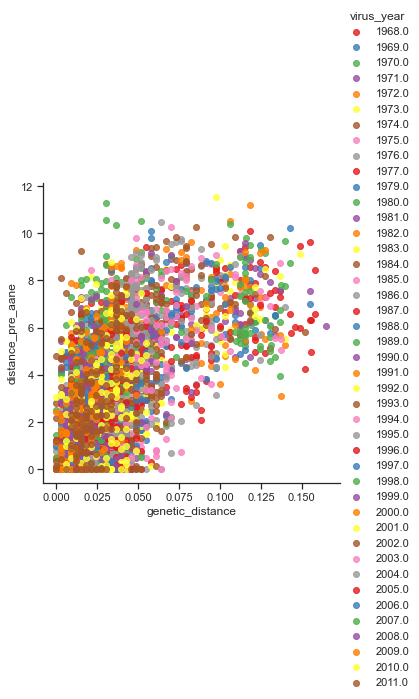

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="ticks", color_codes=True)

sns.lmplot(x="genetic_distance", y="distance_pre_aane",fit_reg = False, hue="virus_year",  palette="Set1",data=distance_all);